In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)

# Better chart size
plt.rcParams['figure.figsize'] = (12,6)

In [ ]:
df = pd.read_csv(
    r"C:\Users\geeta\OneDrive\Desktop\coding\Python\Projects\Business KPI Dashboard\Data\raw_data.csv",
    encoding="latin1"
)

In [5]:
df.head()

df.info()

df.shape

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [7]:
# Total Sales
total_sales = df['Sales'].sum()

print("Total Sales:", round(total_sales,2))

Total Sales: 2297200.86


In [8]:
# Sales by Region
sales_region = (
    df.groupby('Region')['Sales']
    .sum()
    .sort_values(ascending=False)
)

sales_region

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64

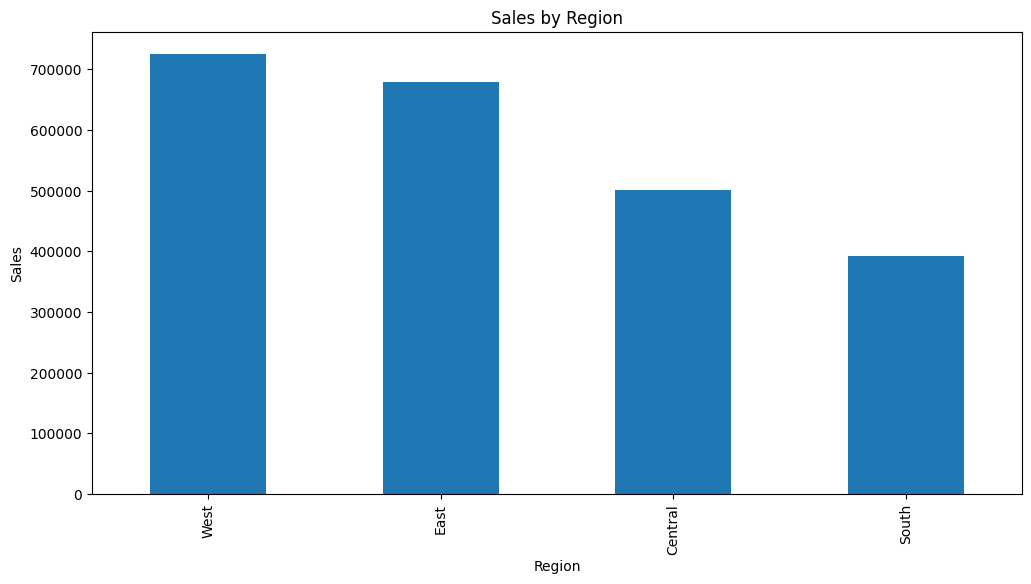

In [9]:
# Visualization
sales_region.plot(
    kind='bar',
    title='Sales by Region'
)

plt.ylabel("Sales")
plt.show()

In [10]:
# Total Profit
total_profit = df['Profit'].sum()

print("Total Profit:", round(total_profit,2))

Total Profit: 286397.02


In [11]:
# Profit by Category
profit_category = (
    df.groupby('Category')['Profit']
    .sum()
    .sort_values(ascending=False)
)

profit_category

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64

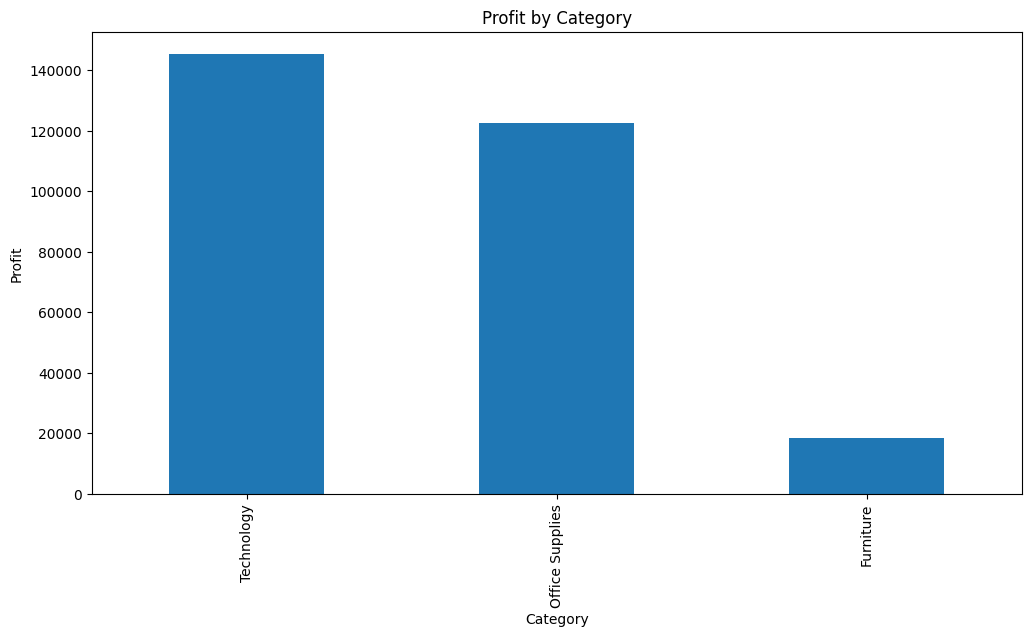

In [12]:
#  Visualization
profit_category.plot(
    kind='bar',
    title='Profit by Category'
)

plt.ylabel("Profit")
plt.show()

In [13]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [14]:
df['Month'] = df['Order Date'].dt.to_period('M')

In [15]:
monthly_sales = (
    df.groupby('Month')['Sales']
    .sum()
)

monthly_sales

Month
2014-01     14236.8950
2014-02      4519.8920
2014-03     55691.0090
2014-04     28295.3450
2014-05     23648.2870
2014-06     34595.1276
2014-07     33946.3930
2014-08     27909.4685
2014-09     81777.3508
2014-10     31453.3930
2014-11     78628.7167
2014-12     69545.6205
2015-01     18174.0756
2015-02     11951.4110
2015-03     38726.2520
2015-04     34195.2085
2015-05     30131.6865
2015-06     24797.2920
2015-07     28765.3250
2015-08     36898.3322
2015-09     64595.9180
2015-10     31404.9235
2015-11     75972.5635
2015-12     74919.5212
2016-01     18542.4910
2016-02     22978.8150
2016-03     51715.8750
2016-04     38750.0390
2016-05     56987.7280
2016-06     40344.5340
2016-07     39261.9630
2016-08     31115.3743
2016-09     73410.0249
2016-10     59687.7450
2016-11     79411.9658
2016-12     96999.0430
2017-01     43971.3740
2017-02     20301.1334
2017-03     58872.3528
2017-04     36521.5361
2017-05     44261.1102
2017-06     52981.7257
2017-07     45264.4160
2017-

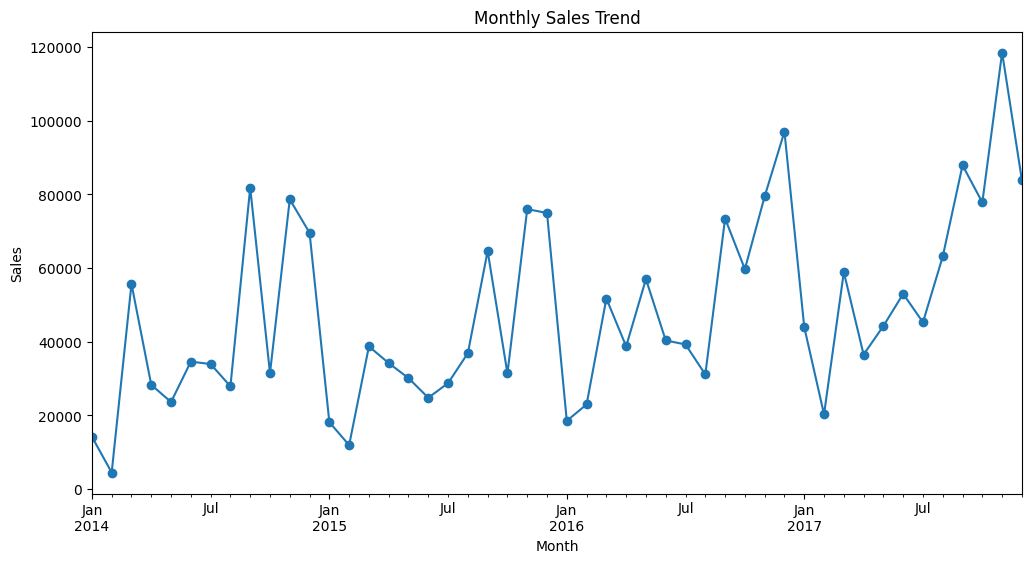

In [16]:
monthly_sales.plot(
    kind='line',
    marker='o',
    title='Monthly Sales Trend'
)

plt.ylabel("Sales")
plt.show()

In [40]:
# Top Customers
top_customers = (
    df.groupby('Customer Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64

In [23]:
#  ----- Top Products----
top_products = (
    df.groupby('Sub-Category')['Sales']
    .sum()
    .sort_values(ascending=False)
)

top_products

Sub-Category
Phones         330007.0540
Chairs         328449.1030
Storage        223843.6080
Tables         206965.5320
Binders        203412.7330
Machines       189238.6310
Accessories    167380.3180
Copiers        149528.0300
Bookcases      114879.9963
Appliances     107532.1610
Furnishings     91705.1640
Paper           78479.2060
Supplies        46673.5380
Art             27118.7920
Envelopes       16476.4020
Labels          12486.3120
Fasteners        3024.2800
Name: Sales, dtype: float64

In [24]:
# Bottom Profit Products
bottom_profit_products = (
    df.groupby('Sub-Category')['Profit']
    .sum()
    .sort_values()
    .head(10)
)

bottom_profit_products

Sub-Category
Tables        -17725.4811
Bookcases      -3472.5560
Supplies       -1189.0995
Fasteners        949.5182
Machines        3384.7569
Labels          5546.2540
Art             6527.7870
Envelopes       6964.1767
Furnishings    13059.1436
Appliances     18138.0054
Name: Profit, dtype: float64

In [25]:
# Correlation
df[['Sales', 'Profit', 'Discount']].corr()

,Sales,Profit,Discount
Sales,1.000000,0.479064,-0.028190
Profit,0.479064,1.000000,-0.219487
Discount,-0.028190,-0.219487,1.000000


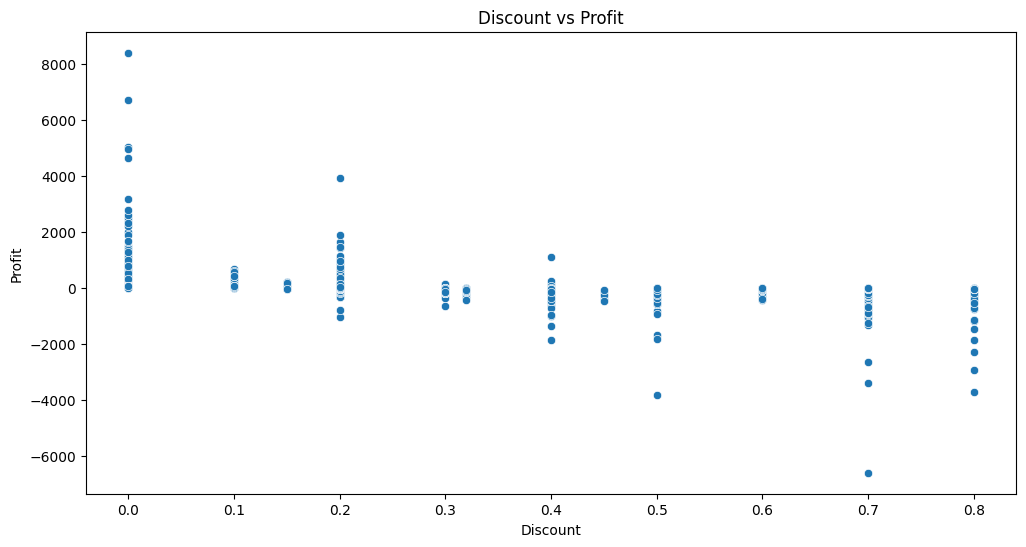

In [26]:
sns.scatterplot(
    data=df,
    x='Discount',
    y='Profit'
)

plt.title("Discount vs Profit")
plt.show()

In [27]:
# Regional Profitability
regional_profit = (
    df.groupby('Region')['Profit']
    .sum()
    .sort_values(ascending=False)
)

regional_profit

Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64

In [28]:
segment_sales = (
    df.groupby('Segment')['Sales']
    .sum()
    .sort_values(ascending=False)
)

segment_sales

Segment
Consumer       1.161401e+06
Corporate      7.061464e+05
Home Office    4.296531e+05
Name: Sales, dtype: float64

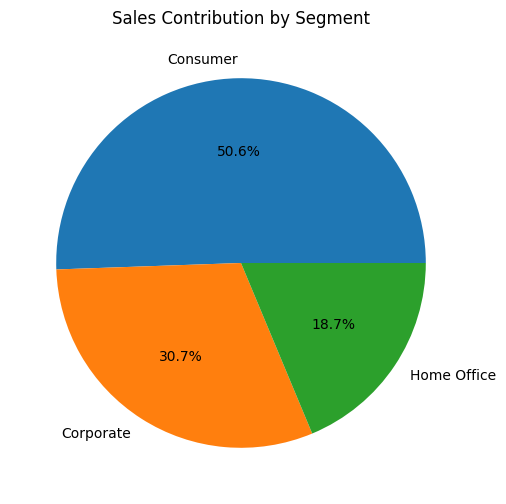

In [33]:
segment_sales.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Sales Contribution by Segment")
plt.ylabel("")
plt.show()

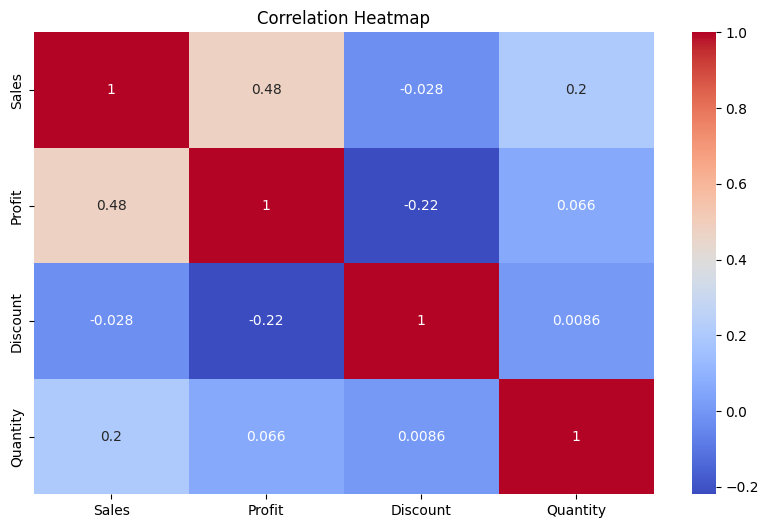

In [39]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df[['Sales', 'Profit', 'Discount', 'Quantity']]
    .corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

BUSINESS INSIGHTS

1. West region generates highest sales.

2. Technology category contributes highest profit.

3. Higher discounts negatively impact profit.

4. Some sub-categories have high sales but low profitability.

5. Consumer segment contributes maximum revenue.

6. Monthly sales show seasonal fluctuations.

7. Certain products consistently generate losses.